Data quality

In [29]:
#eE
import pandas as pd

# Load CSV file
df = pd.read_csv("../TOOL_SALES.csv")

# Show first rows
print(f"number of rows: {len(df)}")

C:\Users\39346\AppData\Local\Temp\ipykernel_18052\1074570744.py:5: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../TOOL_SALES.csv")


number of rows: 2050449


Missing valus

In [30]:
#eE
for col in df.columns:
    missing_count = df[col].isna().sum()
    print(f"{col}: {missing_count} missing values")

YYYYMM: 0 missing values
ITEM_ID: 0 missing values
FLG_TOOL: 0 missing values
SALES_CHANNEL: 0 missing values
NET: 0 missing values
UNIT: 0 missing values
FAMILY_CODE: 0 missing values
GROUP_CODE: 0 missing values
CLIENT_ID: 0 missing values
CANCELLED: 1947739 missing values


Cancelled purchases

In [31]:
count = (df["CANCELLED"] == "X").sum()
print(f"number of cancelled sales: {count}")
df = df[df["CANCELLED"] != "X"]

number of cancelled sales: 102710


In [32]:
min_vals = df.min(numeric_only=True)
max_vals = df.max(numeric_only=True)



print(min_vals)
print(max_vals)

YYYYMM       201701.00
ITEM_ID           1.00
FLG_TOOL          0.00
NET          -13132.97
CLIENT_ID         1.00
dtype: float64
YYYYMM       202112.00
ITEM_ID       14581.00
FLG_TOOL          1.00
NET           59541.92
CLIENT_ID     93257.00
dtype: float64


Plot the sales' trend

YEAR
2017    46682259.83
2018    47231370.52
2019    45296599.82
2020    39239343.42
2021    50189316.01
Name: NET, dtype: float64


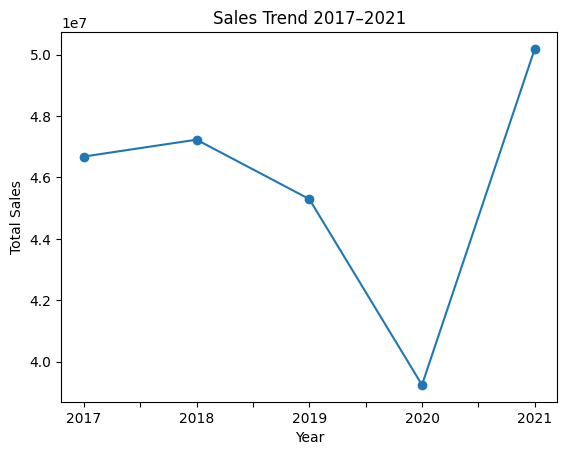

In [33]:
df["YEAR"] = df["YYYYMM"].astype(str).str[:4]
sales_per_year = df.groupby("YEAR")["NET"].sum()
print(sales_per_year)
import matplotlib.pyplot as plt

sales_per_year.plot(marker="o")

plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.title("Sales Trend 2017–2021")

plt.show()

DATE
2017-01-01    3402002.13
2017-02-01    3839744.05
2017-03-01    4204308.58
2017-04-01    4018914.03
2017-05-01    4133638.50
2017-06-01    4054072.27
2017-07-01    4297781.82
2017-08-01    1732390.57
2017-09-01    4114763.39
2017-10-01    4793586.62
2017-11-01    4422760.73
2017-12-01    3668297.14
2018-01-01    3535297.39
2018-02-01    3717146.65
2018-03-01    4020678.97
2018-04-01    3783945.80
2018-05-01    4602259.87
2018-06-01    4041957.09
2018-07-01    4449367.66
2018-08-01    1612338.60
2018-09-01    4307081.58
2018-10-01    4974503.89
2018-11-01    4089066.85
2018-12-01    4097726.17
2019-01-01    3153924.97
2019-02-01    3455477.32
2019-03-01    4025599.65
2019-04-01    3721479.52
2019-05-01    4787126.04
2019-06-01    3474971.62
2019-07-01    4369112.10
2019-08-01    1427655.01
2019-09-01    4501435.92
2019-10-01    4497551.43
2019-11-01    3981021.94
2019-12-01    3901244.30
2020-01-01    3093345.04
2020-02-01    3580219.96
2020-03-01    1954940.98
2020-04-01     57981

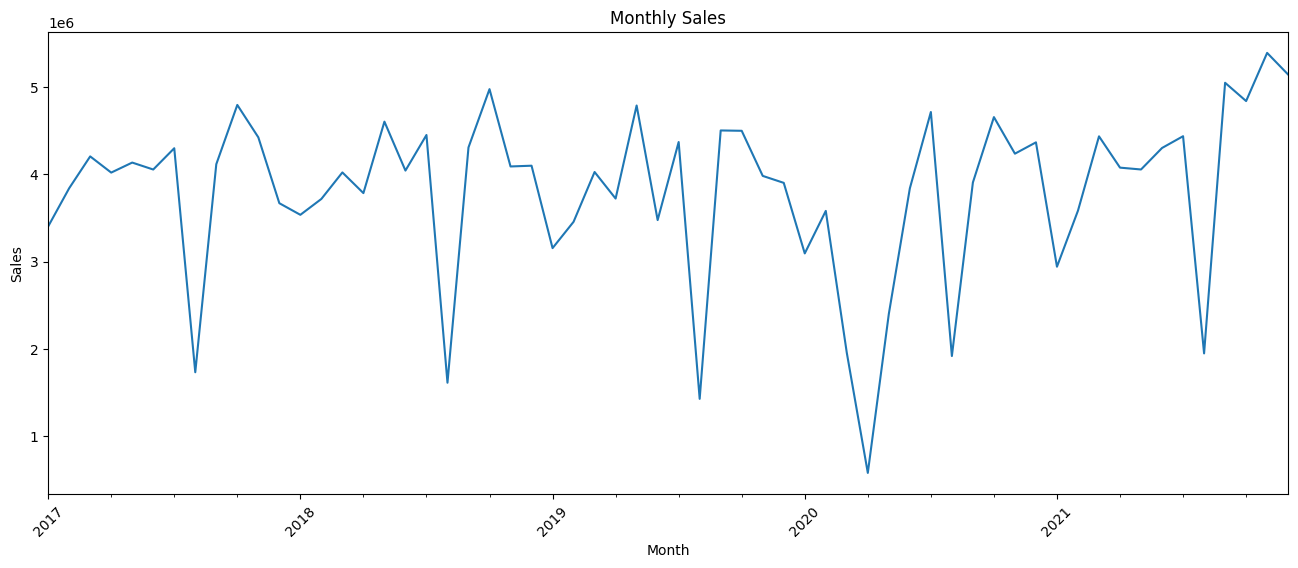

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

# convert YYYYMM to datetime
df["DATE"] = pd.to_datetime(df["YYYYMM"].astype(str), format="%Y%m")

# aggregate sales per month
sales_per_month = df.groupby("DATE")["NET"].sum()

# plot with wider figure
plt.figure(figsize=(16,6))

sales_per_month.plot()
print(sales_per_month)

plt.xlabel("Month")
plt.xticks(rotation=45)
plt.ylabel("Sales")
plt.title("Monthly Sales")

plt.show()

# Sales channel analysis

Which SALES_CHANNEL generates the most sales?

In [35]:
# determine which SALES_CHANNEL generates the most sales by summing the NET values for each channel.
sales_by_channel = df.groupby("SALES_CHANNEL")["NET"].sum()

print(sales_by_channel.sort_values(ascending=False))

SALES_CHANNEL
B    1.469837e+08
C    5.069691e+07
D    2.497800e+07
A    5.980286e+06
Name: NET, dtype: float64


Which channel has the most transactions?

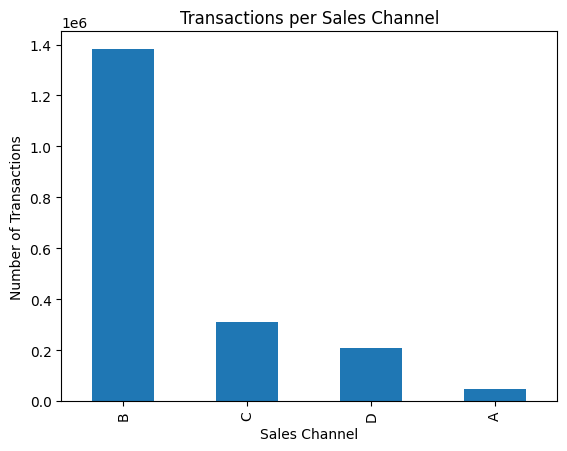

In [36]:
transactions_per_channel = df["SALES_CHANNEL"].value_counts()
import matplotlib.pyplot as plt

transactions_per_channel.plot.bar()

plt.xlabel("Sales Channel")
plt.ylabel("Number of Transactions")
plt.title("Transactions per Sales Channel")

plt.show()

Which channel has the highest average purchase amount?

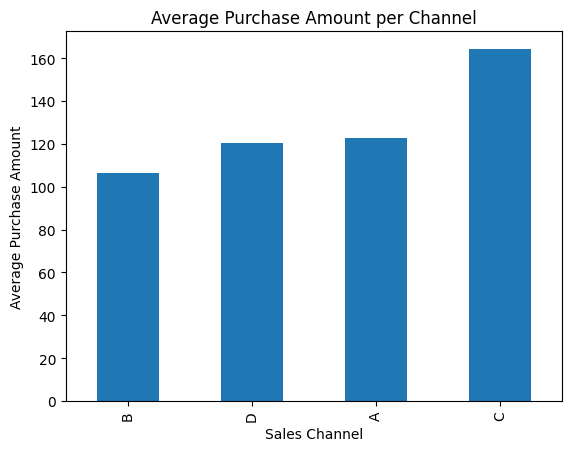

In [37]:
avg_purchase = df.groupby("SALES_CHANNEL")["NET"].mean()
import matplotlib.pyplot as plt

avg_purchase.sort_values().plot.bar()

plt.xlabel("Sales Channel")
plt.ylabel("Average Purchase Amount")
plt.title("Average Purchase Amount per Channel")

plt.show()

# Tool vs non-tool

# Product hierarchy

Which FAMILY_CODE sells most?

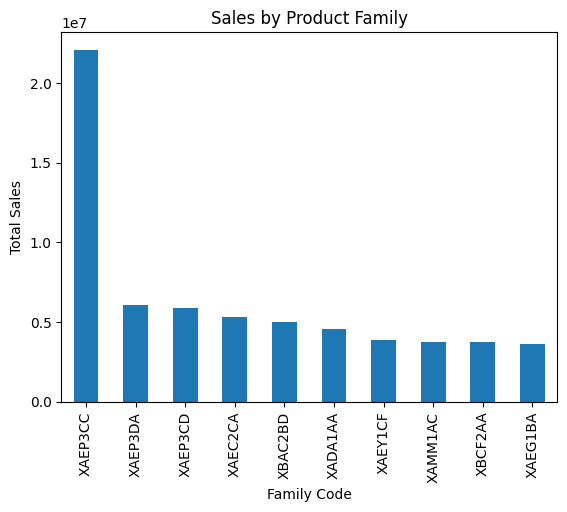

In [38]:
sales_by_family = df.groupby("FAMILY_CODE")["NET"].sum()
import matplotlib.pyplot as plt

sales_by_family.sort_values(ascending=False).head(10).plot.bar()

plt.xlabel("Family Code")
plt.ylabel("Total Sales")
plt.title("Sales by Product Family")

plt.show()

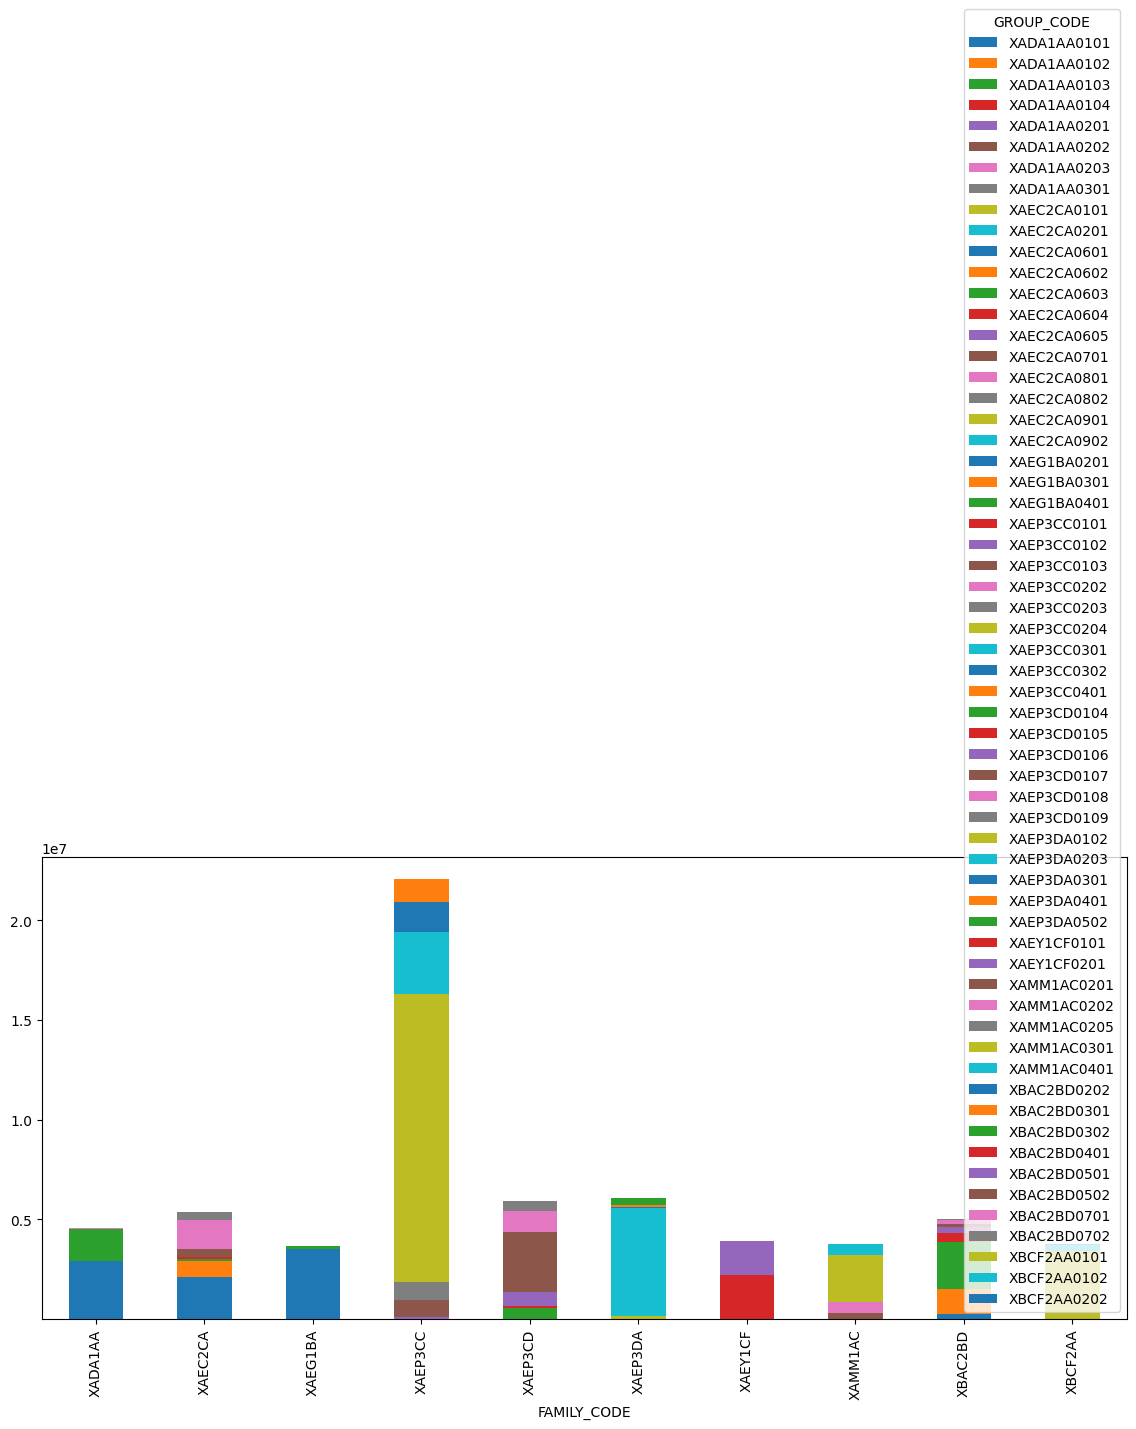

In [39]:
top_families = df.groupby("FAMILY_CODE")["NET"].sum().nlargest(10).index
filtered = df[df["FAMILY_CODE"].isin(top_families)]

pivot = filtered.groupby(["FAMILY_CODE","GROUP_CODE"])["NET"].sum().unstack()

pivot.plot(kind="bar", stacked=True, figsize=(14,6))
plt.show()

#  Pareto analysis

very useful analysis for retail datasets like yours: identifying the top 20 products (ITEM_ID) driving most of the revenue (Pareto 80/20 analysis)

Pareto analysis: identifying the small number of products (ITEM_ID) that generate most of the revenue.

What the chart shows

Bars → sales per ITEM_ID

Red line → cumulative percentage of total revenue

This helps answer:

Which products drive most revenue

Whether 20% of products generate ~80% of sales (typical retail pattern).

               sales  cumulative_%
ITEM_ID                           
3351     14412813.70      6.303745
585       5429038.31      8.678249
3352      3126901.76     10.045865
2469      3014050.29     11.364123
665       2794203.88     12.586226
3959      2747182.81     13.787764
2877      2683649.13     14.961514
3940      2610837.43     16.103419
2748      2428255.20     17.165467
3624      2374747.38     18.204112
13840     2190790.82     19.162300
656       2071758.65     20.068427
3290      1906976.60     20.902483
2284      1743853.58     21.665194
1272      1742963.82     22.427516
1288      1693375.32     23.168149
4795      1528089.78     23.836491
3030      1466400.07     24.477852
1737      1413296.43     25.095987
8628      1402609.59     25.709447


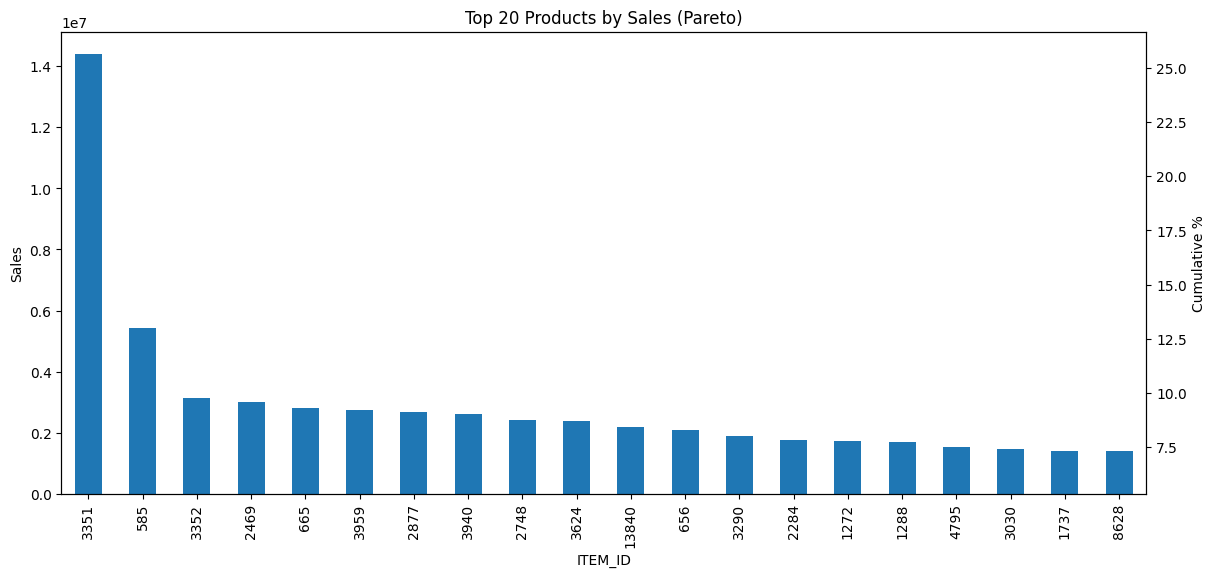

In [24]:
#Compute sales per product
sales_per_item = df.groupby("ITEM_ID")["NET"].sum().sort_values(ascending=False)

#Compute cumulative percentage of sales
cum_sales = sales_per_item.cumsum()
cum_percent = cum_sales / sales_per_item.sum() * 100

pareto = pd.DataFrame({
    "sales": sales_per_item,
    "cumulative_%": cum_percent
})

print(pareto.head(20))

import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(14,6))

sales_per_item.head(20).plot(kind="bar", ax=ax1)
ax1.set_ylabel("Sales")

ax2 = ax1.twinx()
cum_percent.head(20).plot(ax=ax2, color="red", marker="o")
ax2.set_ylabel("Cumulative %")

plt.title("Top 20 Products by Sales (Pareto)")
plt.show()

# Customer behavior

Total number of unique customers

In [40]:
unique_customers = df["CLIENT_ID"].nunique()
print(unique_customers)

85714


Unique customers per month

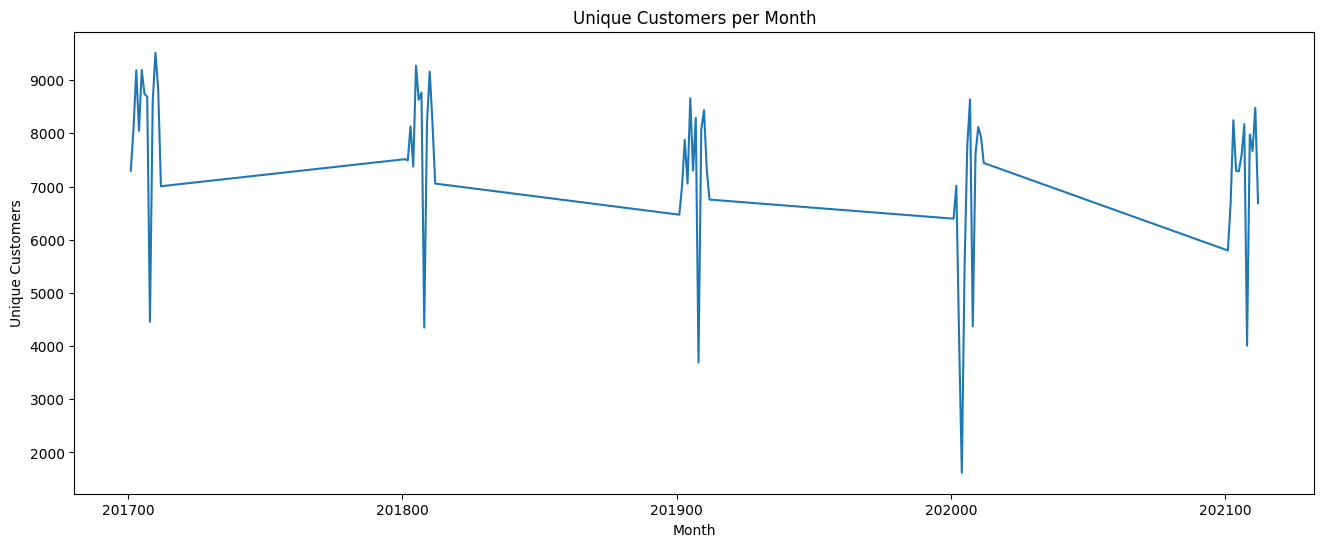

In [41]:
customers_per_month = df.groupby("YYYYMM")["CLIENT_ID"].nunique()
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))
customers_per_month.plot()

plt.xlabel("Month")
plt.ylabel("Unique Customers")
plt.title("Unique Customers per Month")

plt.show()

Unique customers per sales channel

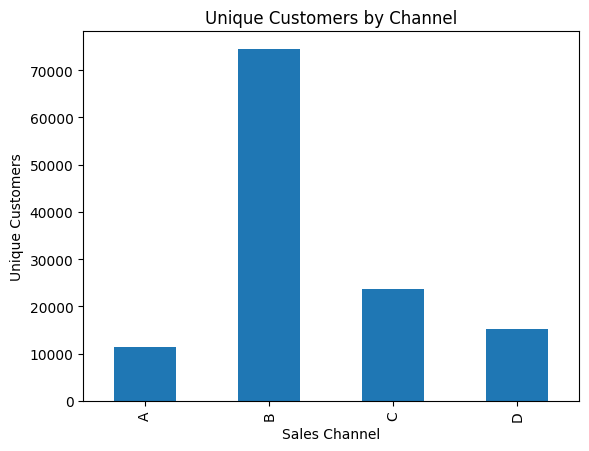

In [27]:
customers_by_channel = df.groupby("SALES_CHANNEL")["CLIENT_ID"].nunique()

customers_by_channel.plot.bar()

plt.xlabel("Sales Channel")
plt.ylabel("Unique Customers")
plt.title("Unique Customers by Channel")

plt.show()

customer growth over time

In [42]:
df.groupby("YYYYMM")["CLIENT_ID"].nunique()

YYYYMM
201701    7295
201702    8088
201703    9185
201704    8048
201705    9192
201706    8742
201707    8689
201708    4457
201709    8597
201710    9517
201711    8839
201712    7006
201801    7515
201802    7491
201803    8132
201804    7375
201805    9273
201806    8630
201807    8769
201808    4347
201809    8187
201810    9163
201811    8189
201812    7056
201901    6471
201902    7019
201903    7878
201904    7057
201905    8661
201906    7302
201907    8294
201908    3690
201909    8070
201910    8436
201911    7322
201912    6755
202001    6396
202002    7016
202003    4170
202004    1618
202005    5470
202006    7779
202007    8639
202008    4371
202009    7623
202010    8120
202011    7931
202012    7443
202101    5798
202102    6677
202103    8247
202104    7295
202105    7285
202106    7597
202107    8174
202108    4006
202109    7979
202110    7669
202111    8480
202112    6687
Name: CLIENT_ID, dtype: int64

How many purchases per customer?

Which customers generate the most revenue?

Is the business concentrated in a few clients?

# Distribution of NET / Price / transaction amount behavior

Is NET highly skewed?

Are there outliers?

Are there negative values?

Are cancelled rows causing strange amounts?